In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)
pd.set_option("display.max_colwidth", None)

In [34]:
df=pd.read_csv('/content/train.csv')

df

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,70,62,199,58,114,102,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,77,71,199,50,121,124,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,89,73,188,59,114,108,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,69,74,182,54,85,123,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,60,85,206,49,131,124,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699995,699995,29,1,59,6.9,5.2,1.5,26.1,0.88,133,57,69,163,58,90,126,Female,Hispanic,Postgraduate,Upper-Middle,Former,Employed,0,0,0,0.0
699996,699996,46,2,72,7.7,7.7,3.8,25.5,0.85,106,85,65,188,45,107,119,Female,Hispanic,Graduate,Upper-Middle,Former,Employed,0,0,1,1.0
699997,699997,35,1,50,5.6,6.1,6.4,26.9,0.88,127,84,63,168,59,77,166,Female,White,Graduate,Middle,Never,Employed,0,0,0,1.0
699998,699998,49,2,70,5.7,6.9,4.7,25.2,0.86,116,67,69,198,55,108,133,Female,White,Highschool,Lower-Middle,Never,Retired,0,0,0,1.0


In [35]:
print(df.describe())
print(df.info())

                  id            age  alcohol_consumption_per_week  \
count  700000.000000  700000.000000                 700000.000000   
mean   349999.500000      50.359734                      2.072411   
std    202072.738554      11.655520                      1.048189   
min         0.000000      19.000000                      1.000000   
25%    174999.750000      42.000000                      1.000000   
50%    349999.500000      50.000000                      2.000000   
75%    524999.250000      58.000000                      3.000000   
max    699999.000000      89.000000                      9.000000   

       physical_activity_minutes_per_week     diet_score  sleep_hours_per_day  \
count                       700000.000000  700000.000000        700000.000000   
mean                            80.230803       5.963695             7.002200   
std                             51.195071       1.463336             0.901907   
min                              1.000000       0.1000

In [36]:
df[df['diagnosed_diabetes']==1].describe()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
count,436307.000000,436307.000000,436307.000000,436307.000000,436307.000000,436307.00000,436307.000000,436307.000000,436307.000000,436307.000000,436307.000000,436307.000000,436307.000000,436307.000000,436307.000000,436307.000000,436307.000000,436307.000000,436307.000000,436307.0
mean,349987.647755,51.820056,2.074849,73.473245,5.906678,7.00466,6.041372,26.109489,0.861159,117.211202,75.633393,70.296482,187.964860,53.481125,104.425668,124.825022,0.207895,0.190982,0.033623,1.0
std,201894.033765,11.593097,1.045364,43.428555,1.459453,0.90057,2.019437,2.852350,0.037819,11.031119,6.820969,6.917040,16.749371,8.310381,18.994343,24.852648,0.405802,0.393076,0.180257,0.0
min,0.000000,19.000000,1.000000,1.000000,0.100000,3.20000,0.600000,15.100000,0.690000,91.000000,51.000000,42.000000,117.000000,21.000000,51.000000,31.000000,0.000000,0.000000,0.000000,1.0
25%,175195.000000,44.000000,1.000000,46.000000,4.900000,6.40000,4.600000,24.200000,0.840000,109.000000,71.000000,66.000000,176.000000,48.000000,91.000000,108.000000,0.000000,0.000000,0.000000,1.0
50%,350061.000000,52.000000,2.000000,65.000000,5.900000,7.00000,6.000000,26.100000,0.860000,117.000000,76.000000,70.000000,188.000000,54.000000,104.000000,124.000000,0.000000,0.000000,0.000000,1.0
75%,524593.500000,60.000000,3.000000,90.000000,6.900000,7.60000,7.400000,28.000000,0.890000,125.000000,80.000000,75.000000,200.000000,59.000000,118.000000,140.000000,0.000000,0.000000,0.000000,1.0
max,699999.000000,89.000000,9.000000,747.000000,9.900000,9.90000,16.500000,38.400000,1.020000,163.000000,104.000000,101.000000,286.000000,90.000000,204.000000,286.000000,1.000000,1.000000,1.000000,1.0


In [37]:
df[df['diagnosed_diabetes']==0].describe()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
count,263693.000000,263693.000000,263693.000000,263693.000000,263693.000000,263693.000000,263693.000000,263693.000000,263693.000000,263693.000000,263693.000000,263693.000000,263693.000000,263693.000000,263693.000000,263693.000000,263693.000000,263693.000000,263693.000000,263693.0
mean,350019.110750,47.943484,2.068379,91.411873,6.058035,6.998129,5.965346,25.486175,0.854806,114.776907,75.122464,69.954747,184.922531,54.389237,100.391167,120.197593,0.052618,0.167111,0.024866,0.0
std,202368.458826,11.352802,1.052838,60.302019,1.464877,0.904101,2.027223,2.832044,0.037914,10.806463,6.821817,6.969243,16.526515,8.162087,18.800903,24.277571,0.223270,0.373076,0.155717,0.0
min,2.000000,19.000000,1.000000,3.000000,0.100000,3.100000,0.600000,15.100000,0.680000,91.000000,51.000000,42.000000,117.000000,21.000000,51.000000,31.000000,0.000000,0.000000,0.000000,0.0
25%,174688.000000,40.000000,1.000000,54.000000,5.100000,6.400000,4.500000,23.600000,0.830000,107.000000,70.000000,65.000000,173.000000,49.000000,87.000000,103.000000,0.000000,0.000000,0.000000,0.0
50%,349930.000000,48.000000,2.000000,79.000000,6.100000,7.000000,5.900000,25.500000,0.850000,115.000000,75.000000,70.000000,185.000000,54.000000,100.000000,120.000000,0.000000,0.000000,0.000000,0.0
75%,525604.000000,56.000000,3.000000,107.000000,7.100000,7.600000,7.300000,27.400000,0.880000,122.000000,80.000000,75.000000,197.000000,60.000000,114.000000,136.000000,0.000000,0.000000,0.000000,0.0
max,699995.000000,89.000000,9.000000,705.000000,9.900000,9.900000,15.900000,38.400000,1.050000,163.000000,104.000000,99.000000,289.000000,86.000000,205.000000,290.000000,1.000000,1.000000,1.000000,0.0


In [38]:
df['diagnosed_diabetes'].value_counts(normalize=True)

,proportion
diagnosed_diabetes,
1.0,0.623296
0.0,0.376704


In [39]:
df.columns

Index(['id', 'age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'gender', 'ethnicity', 'education_level',
       'income_level', 'smoking_status', 'employment_status',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'diagnosed_diabetes'],
      dtype='object')

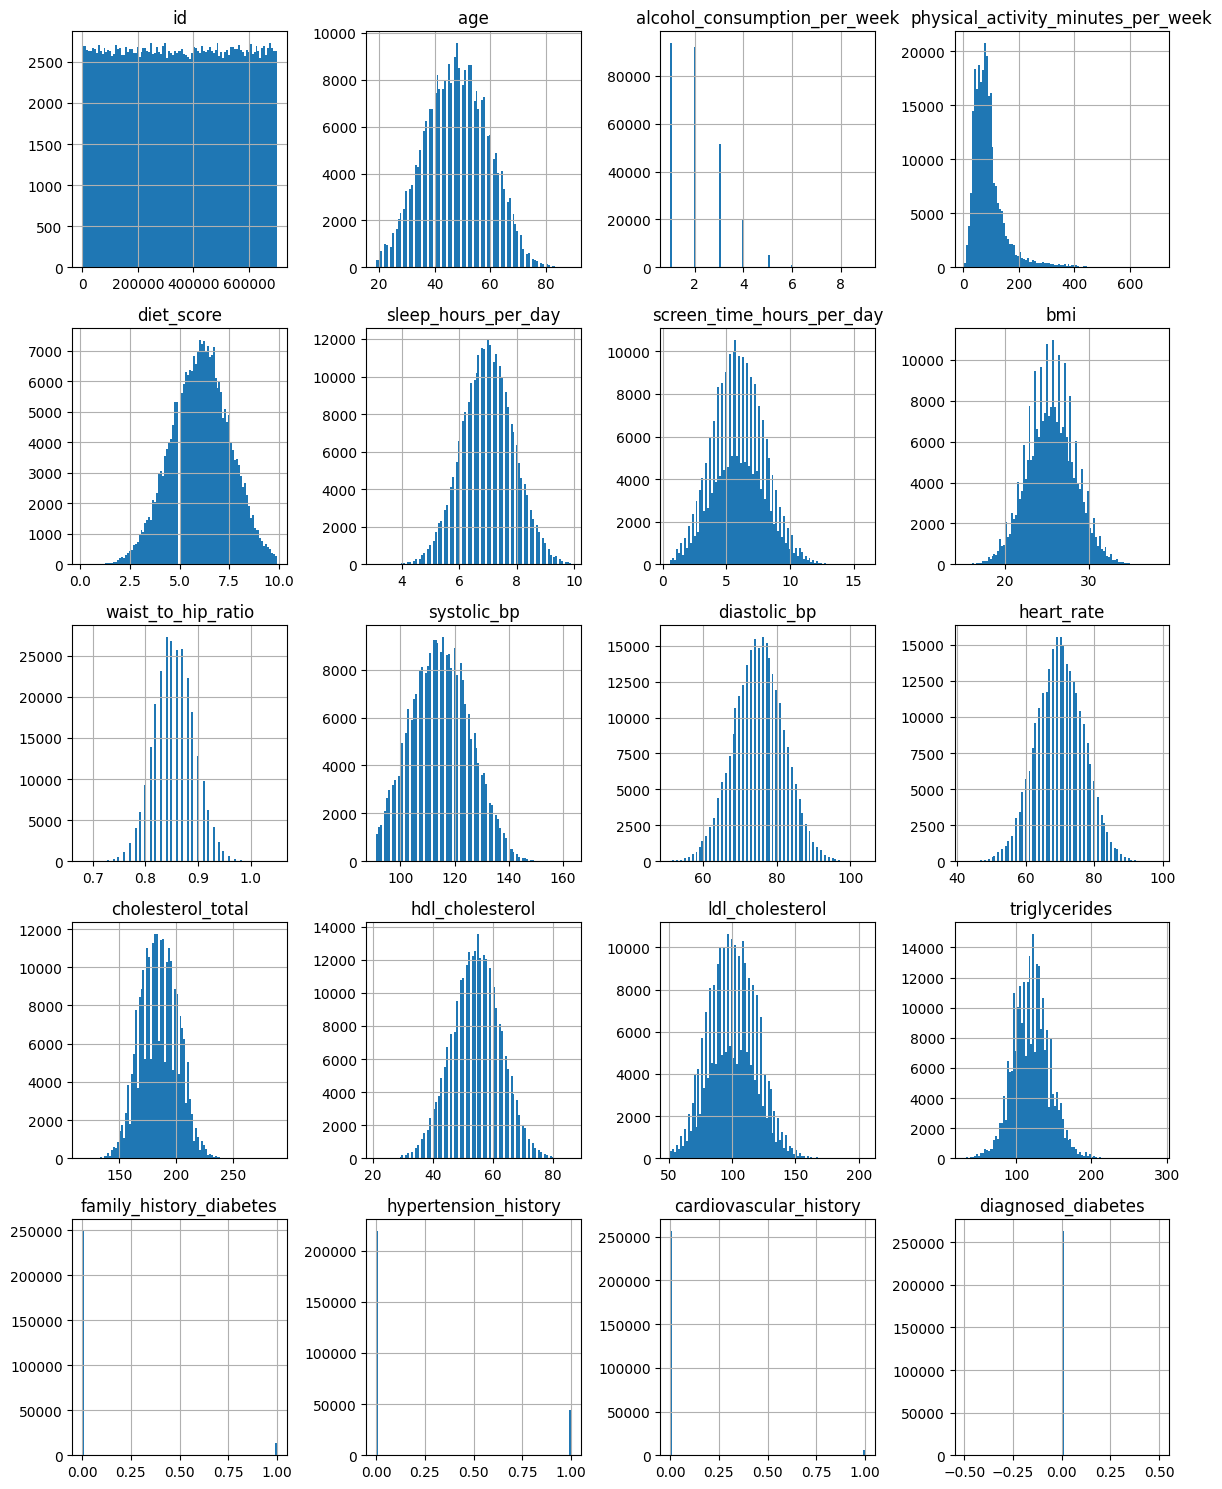

In [40]:
df[df['diagnosed_diabetes']==0].hist(figsize=(12,15),bins=100)
plt.tight_layout()

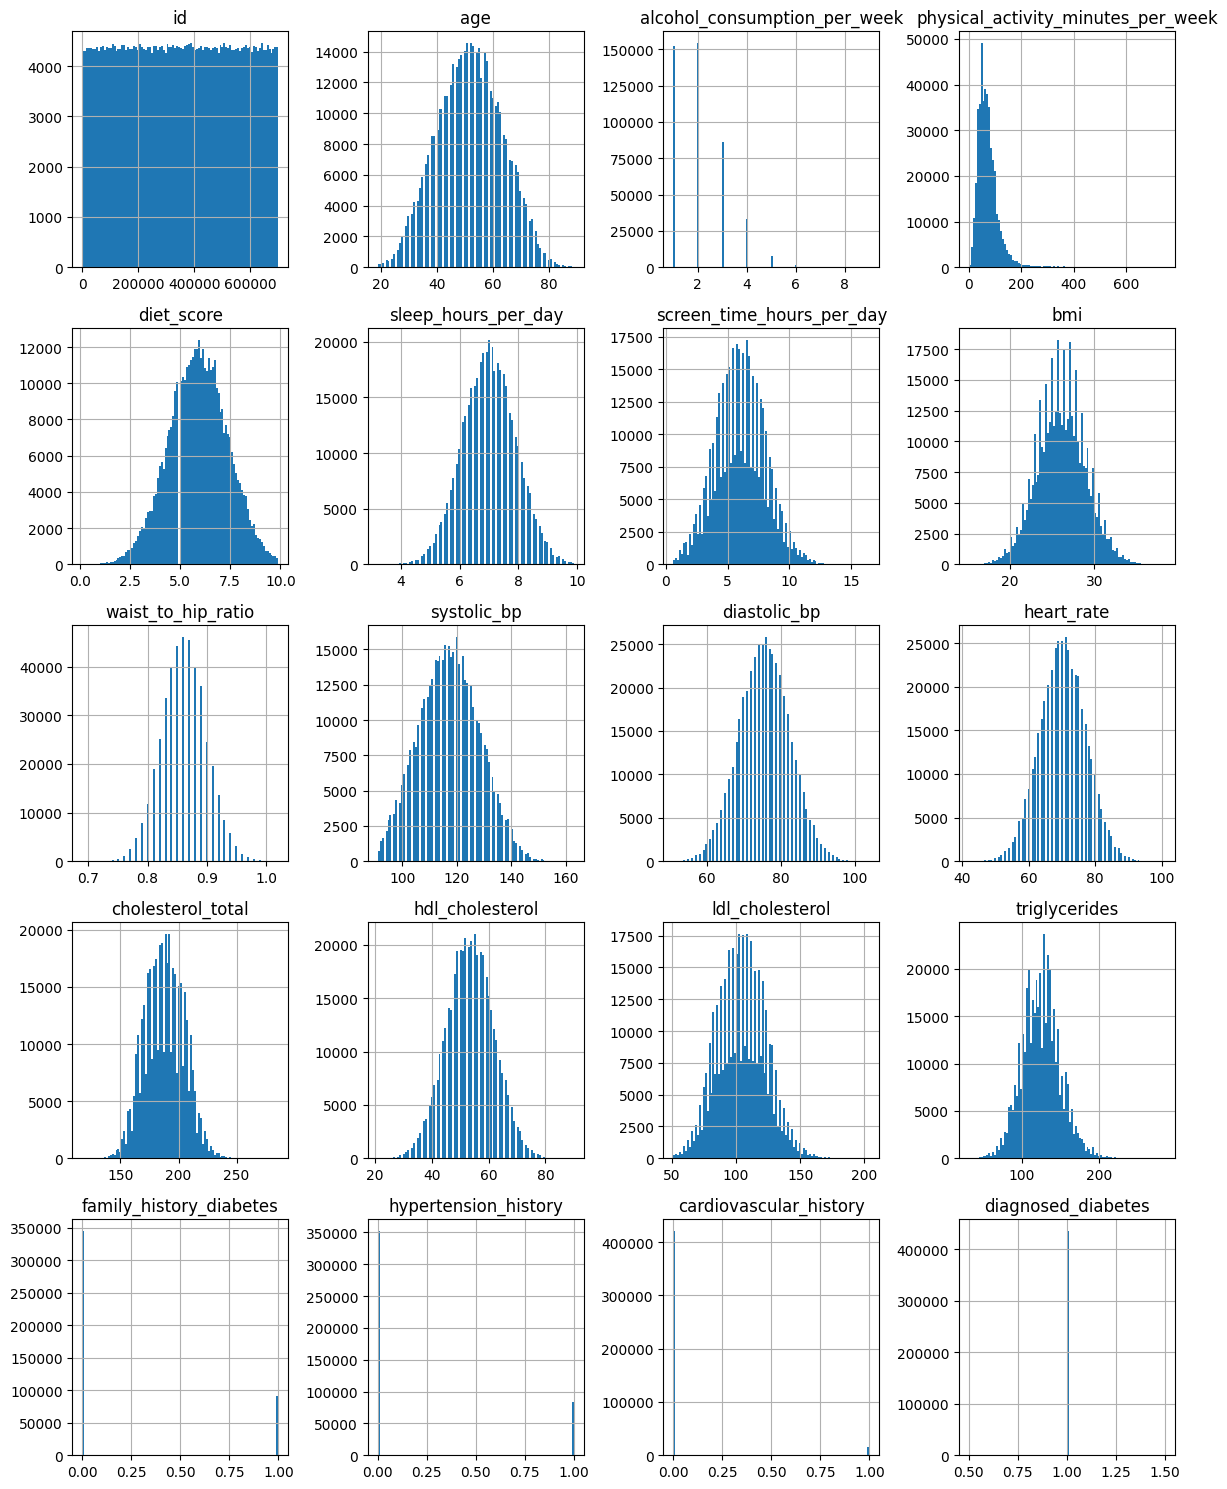

In [41]:
df[df['diagnosed_diabetes']==1].hist(figsize=(12,15),bins=100)
plt.tight_layout()

In [60]:
cat_cols=['gender', 'ethnicity', 'education_level',
       'income_level', 'smoking_status', 'employment_status',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history']

In [42]:
scaler=StandardScaler()
num_cols=['age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides']

'''df[num_cols]=scaler.fit_transform(df[num_cols])'''

df.groupby(['diagnosed_diabetes','gender'])[num_cols].agg('mean')

age  alcohol_consumption_per_week  \
diagnosed_diabetes gender                                            
0.0                Female  47.989018                      2.070350   
                   Male    47.891643                      2.066540   
                   Other   48.124054                      2.037821   
1.0                Female  51.828449                      2.075896   
                   Male    51.814194                      2.073357   
                   Other   51.532258                      2.106112   

                           physical_activity_minutes_per_week  diet_score  \
diagnosed_diabetes gender                                                   
0.0                Female                           91.146274    6.059864   
                   Male                             91.710793    6.055949   
                   Other                            90.686082    6.065582   
1.0                Female                           73.524114    5.906980   
                   Male                             73.417052    5.906085   
                   Other                            73.553056    5.930051   

                           sleep_hours_per_day  screen_time_hours_per_day  \
diagnosed_diabetes gender                                                   
0.0                Female             6.996399                   5.960948   
                   Male               7.000263                   5.970136   
                   Other              6.975794                   5.968533   
1.0                Female             7.004121                   6.037890   
                   Male               7.005248                   6.045623   
                   Other              7.004499                   6.000297   

                                 bmi  waist_to_hip_ratio  systolic_bp  \
diagnosed_diabetes gender                                               
0.0                Female  25.486783            0.854857   114.811155   
                   Male    25.486734            0.854758   114.737874   
                   Other   25.370121            0.854160   114.916793   
1.0                Female  26.117314            0.861207   117.252841   
                   Male    26.102149            0.861110   117.166704   
                   Other   26.006621            0.860811   117.144312   

                           diastolic_bp  heart_rate  cholesterol_total  \
diagnosed_diabetes gender                                                
0.0                Female     75.129207   69.975712         184.947446   
                   Male       75.116803   69.926987         184.894464   
                   Other      74.958396   70.406203         184.993192   
1.0                Female     75.624748   70.284189         187.952763   
                   Male       75.643705   70.305060         187.988478   
                   Other      75.552632   70.718591         187.040747   

                           hdl_cholesterol  ldl_cholesterol  triglycerides  
diagnosed_diabetes gender                                                   
0.0                Female        54.423934       100.394042     120.272268  
                   Male          54.346071       100.391603     120.114854  
                   Other         54.873676       100.051437     120.278366  
1.0                Female        53.493071       104.410211     124.887787  
                   Male          53.467989       104.452855     124.767028  
                   Other         53.494482       103.508913     123.922750

In [43]:
df.groupby('diagnosed_diabetes')[num_cols].agg('std')

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides
diagnosed_diabetes,,,,,,,,,,,,,,,
0.0,11.352802,1.052838,60.302019,1.464877,0.904101,2.027223,2.832044,0.037914,10.806463,6.821817,6.969243,16.526515,8.162087,18.800903,24.277571
1.0,11.593097,1.045364,43.428555,1.459453,0.900570,2.019437,2.852350,0.037819,11.031119,6.820969,6.917040,16.749371,8.310381,18.994343,24.852648


In [44]:
df.groupby(['diagnosed_diabetes','gender'])[num_cols].agg('median')

age  alcohol_consumption_per_week  \
diagnosed_diabetes gender                                       
0.0                Female  48.0                           2.0   
                   Male    48.0                           2.0   
                   Other   48.0                           2.0   
1.0                Female  52.0                           2.0   
                   Male    52.0                           2.0   
                   Other   51.0                           2.0   

                           physical_activity_minutes_per_week  diet_score  \
diagnosed_diabetes gender                                                   
0.0                Female                                79.0         6.1   
                   Male                                  79.0         6.1   
                   Other                                 77.0         6.1   
1.0                Female                                65.0         5.9   
                   Male                                  65.0         5.9   
                   Other                                 67.0         6.0   

                           sleep_hours_per_day  screen_time_hours_per_day  \
diagnosed_diabetes gender                                                   
0.0                Female                  7.0                        5.9   
                   Male                    7.0                        5.9   
                   Other                   7.0                        5.8   
1.0                Female                  7.0                        6.0   
                   Male                    7.0                        6.0   
                   Other                   7.0                        6.0   

                            bmi  waist_to_hip_ratio  systolic_bp  \
diagnosed_diabetes gender                                          
0.0                Female  25.5                0.85        115.0   
                   Male    25.5                0.85        115.0   
                   Other   25.3                0.85        115.0   
1.0                Female  26.1                0.86        117.0   
                   Male    26.1                0.86        117.0   
                   Other   25.9                0.86        117.0   

                           diastolic_bp  heart_rate  cholesterol_total  \
diagnosed_diabetes gender                                                
0.0                Female          75.0        70.0              185.0   
                   Male            75.0        70.0              185.0   
                   Other           75.0        70.0              185.0   
1.0                Female          76.0        70.0              188.0   
                   Male            76.0        70.0              188.0   
                   Other           75.0        71.0              187.0   

                           hdl_cholesterol  ldl_cholesterol  triglycerides  
diagnosed_diabetes gender                                                   
0.0                Female             55.0            100.0          120.0  
                   Male               54.0            100.0          120.0  
                   Other              55.0             99.0          119.5  
1.0                Female             54.0            104.0          125.0  
                   Male               53.0            104.0          124.0  
                   Other              53.0            103.0          124.0

In [45]:
df.groupby(['diagnosed_diabetes','gender'])[num_cols].agg(pd.Series.mode)

age  alcohol_consumption_per_week  \
diagnosed_diabetes gender                                      
0.0                Female   48                             1   
                   Male     48                             1   
                   Other    53                             2   
1.0                Female   52                             2   
                   Male     51                             2   
                   Other    51                             2   

                           physical_activity_minutes_per_week  diet_score  \
diagnosed_diabetes gender                                                   
0.0                Female                                  81         6.0   
                   Male                                    81         6.2   
                   Other                                   40  [5.9, 6.5]   
1.0                Female                                  63         5.9   
                   Male                                    63         5.9   
                   Other                                   39         6.4   

                           sleep_hours_per_day  screen_time_hours_per_day  \
diagnosed_diabetes gender                                                   
0.0                Female                  7.0                        5.8   
                   Male                    7.0                        5.8   
                   Other                   6.7                        4.8   
1.0                Female                  7.0                        6.1   
                   Male                    7.0                        6.6   
                   Other                   7.1                        6.7   

                            bmi  waist_to_hip_ratio  systolic_bp  \
diagnosed_diabetes gender                                          
0.0                Female  25.7                0.84          113   
                   Male    25.7                0.84          116   
                   Other   25.8                0.84          114   
1.0                Female  25.7                0.86          120   
                   Male    25.9                0.86          120   
                   Other   25.1                0.87          123   

                           diastolic_bp  heart_rate  cholesterol_total  \
diagnosed_diabetes gender                                                
0.0                Female            76          70                187   
                   Male              74          69                185   
                   Other             77          69                184   
1.0                Female            76          71                189   
                   Male              76          71                189   
                   Other             78          71                190   

                           hdl_cholesterol  ldl_cholesterol  triglycerides  
diagnosed_diabetes gender                                                   
0.0                Female               55               91            117  
                   Male                 55               97            108  
                   Other                58               99            117  
1.0                Female               55              106            117  
                   Male                 55              102            122  
                   Other                51               91            132

In [46]:
df.duplicated().value_counts()

,count
False,700000


In [47]:
for col in df.drop(['id'],axis=1).columns:
  print(df[col].value_counts())

age
52    23229
48    23119
53    22994
51    22980
49    22265
47    21978
50    21803
55    21749
57    21095
54    21055
46    21036
58    20684
45    20522
44    19129
56    19048
43    18710
41    18459
42    17870
59    17010
60    16648
40    16322
62    15568
39    15254
38    15248
61    15121
63    14103
37    13549
64    12665
36    12508
65    11693
35    10865
67     9881
66     9765
34     9417
68     8917
33     8687
69     8029
32     7745
31     6776
30     6608
70     6498
71     5875
29     5156
72     4891
28     4348
74     3773
27     3647
73     3594
26     2765
75     2694
25     2336
76     1787
77     1511
22     1490
24     1362
23     1338
78     1090
79     1079
21      961
80      636
81      619
19      546
20      519
82      368
83      288
85      198
84      180
86      126
87       89
88       77
89       55
Name: count, dtype: int64
alcohol_consumption_per_week
2    246592
1    246311
3    137565
4     52973
5     13322
6      2728
7       447
8    

In [48]:
df[['diagnosed_diabetes','cardiovascular_history','hypertension_history','family_history_diabetes']]=df[['diagnosed_diabetes','cardiovascular_history','hypertension_history','family_history_diabetes']].astype(bool)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  700000 non-null  int64  
 1   age                                 700000 non-null  int64  
 2   alcohol_consumption_per_week        700000 non-null  int64  
 3   physical_activity_minutes_per_week  700000 non-null  int64  
 4   diet_score                          700000 non-null  float64
 5   sleep_hours_per_day                 700000 non-null  float64
 6   screen_time_hours_per_day           700000 non-null  float64
 7   bmi                                 700000 non-null  float64
 8   waist_to_hip_ratio                  700000 non-null  float64
 9   systolic_bp                         700000 non-null  int64  
 10  diastolic_bp                        700000 non-null  int64  
 11  heart_rate                

In [50]:
df.drop('id',axis=1).nunique()

,0
age,71
alcohol_consumption_per_week,9
physical_activity_minutes_per_week,565
diet_score,99
sleep_hours_per_day,69
screen_time_hours_per_day,151
bmi,231
waist_to_hip_ratio,36
systolic_bp,71
diastolic_bp,54


In [51]:
df.groupby(['diagnosed_diabetes','ethnicity'])[num_cols].agg('mean')

age  alcohol_consumption_per_week  \
diagnosed_diabetes ethnicity                                            
False              Asian      47.953884                      2.067876   
                   Black      47.997974                      2.063554   
                   Hispanic   47.920137                      2.065386   
                   Other      47.800315                      2.058740   
                   White      47.941159                      2.071235   
True               Asian      51.773402                      2.069525   
                   Black      51.898611                      2.074081   
                   Hispanic   51.839086                      2.073311   
                   Other      51.652001                      2.046881   
                   White      51.807162                      2.077693   

                              physical_activity_minutes_per_week  diet_score  \
diagnosed_diabetes ethnicity                                                   
False              Asian                               91.065592    6.077269   
                   Black                               91.034265    6.058929   
                   Hispanic                            91.047440    6.061885   
                   Other                               91.571969    6.068835   
                   White                               91.687378    6.053034   
True               Asian                               72.950774    5.926370   
                   Black                               73.293385    5.900783   
                   Hispanic                            73.409220    5.906623   
                   Other                               74.190768    5.911233   
                   White                               73.592913    5.905021   

                              sleep_hours_per_day  screen_time_hours_per_day  \
diagnosed_diabetes ethnicity                                                   
False              Asian                 7.000882                   5.950468   
                   Black                 6.994635                   5.976289   
                   Hispanic              6.997333                   5.949540   
                   Other                 7.034898                   5.950000   
                   White                 6.997333                   5.970723   
True               Asian                 7.014871                   6.030086   
                   Black                 7.001268                   6.038950   
                   Hispanic              7.002378                   6.033522   
                   Other                 7.015903                   6.032402   
                   White                 7.004233                   6.046831   

                                    bmi  waist_to_hip_ratio  systolic_bp  \
diagnosed_diabetes ethnicity                                               
False              Asian      25.492232            0.854949   114.787374   
                   Black      25.501898            0.855104   114.745836   
                   Hispanic   25.508357            0.855059   114.707898   
                   Other      25.468709            0.854896   114.782992   
                   White      25.474054            0.854612   114.807300   
True               Asian      26.135633            0.861252   117.217414   
                   Black      26.134019            0.861496   117.278457   
                   Hispanic   26.108226            0.861296   117.115090   
                   Other      26.052083            0.860589   117.180581   
                   White      26.101702            0.861032   117.225079   

                              diastolic_bp  heart_rate  cholesterol_total  \
diagnosed_diabetes ethnicity                                                
False              Asian         75.074099   70.021491         185.205910   
                   Black         75.172202   70.012381         184.830949   
                

In [52]:
df.groupby(['diagnosed_diabetes','ethnicity'])[num_cols].agg('median')

age  alcohol_consumption_per_week  \
diagnosed_diabetes ethnicity                                       
False              Asian      48.0                           2.0   
                   Black      48.0                           2.0   
                   Hispanic   48.0                           2.0   
                   Other      48.0                           2.0   
                   White      48.0                           2.0   
True               Asian      52.0                           2.0   
                   Black      52.0                           2.0   
                   Hispanic   52.0                           2.0   
                   Other      51.0                           2.0   
                   White      52.0                           2.0   

                              physical_activity_minutes_per_week  diet_score  \
diagnosed_diabetes ethnicity                                                   
False              Asian                                    78.0         6.1   
                   Black                                    79.0         6.1   
                   Hispanic                                 78.0         6.1   
                   Other                                    78.0         6.1   
                   White                                    79.0         6.1   
True               Asian                                    65.0         5.9   
                   Black                                    65.0         5.9   
                   Hispanic                                 65.0         5.9   
                   Other                                    66.0         5.9   
                   White                                    66.0         5.9   

                              sleep_hours_per_day  screen_time_hours_per_day  \
diagnosed_diabetes ethnicity                                                   
False              Asian                      7.0                        5.9   
                   Black                      7.0                        5.9   
                   Hispanic                   7.0                        5.9   
                   Other                      7.0                        5.9   
                   White                      7.0                        5.9   
True               Asian                      7.0                        6.0   
                   Black                      7.0                        6.0   
                   Hispanic                   7.0                        6.0   
                   Other                      7.0                        6.0   
                   White                      7.0                        6.0   

                               bmi  waist_to_hip_ratio  systolic_bp  \
diagnosed_diabetes ethnicity                                          
False              Asian      25.5                0.85        115.0   
                   Black      25.5                0.85        115.0   
                   Hispanic   25.5                0.85        115.0   
                   Other      25.4                0.85        115.0   
                   White      25.5                0.85        115.0   
True               Asian      26.1                0.86        117.0   
                   Black      26.1                0.86        117.0   
                   Hispanic   26.1                0.86        117.0   
                   Other      26.0                0.86        117.0   
                   White      26.1                0.86        117.0   

                              diastolic_bp  heart_rate  cholesterol_total  \
diagnosed_diabetes ethnicity                                                
False              Asian              75.0        70.0              185.0   
                   Black              75.0        70.0              184.0   
                   Hispanic           75.0        70.0              185.0   
                   Other              75.0        70.0

In [53]:
df.groupby(['diagnosed_diabetes','ethnicity'])[num_cols].agg(pd.Series.mode)

age  alcohol_consumption_per_week  \
diagnosed_diabetes ethnicity                                      
False              Asian       47                             2   
                   Black       48                             1   
                   Hispanic    48                             1   
                   Other       47                             1   
                   White       48                             1   
True               Asian       55                             2   
                   Black       53                             2   
                   Hispanic    57                             2   
                   Other       50                             1   
                   White       52                             2   

                              physical_activity_minutes_per_week  diet_score  \
diagnosed_diabetes ethnicity                                                   
False              Asian                                      81         6.0   
                   Black                                      81         6.0   
                   Hispanic                                   81         6.1   
                   Other                                      60  [5.7, 5.9]   
                   White                                      81         6.2   
True               Asian                                      63         5.8   
                   Black                                      63         5.7   
                   Hispanic                                   63         5.9   
                   Other                                      50         5.9   
                   White                                      63         5.9   

                              sleep_hours_per_day  screen_time_hours_per_day  \
diagnosed_diabetes ethnicity                                                   
False              Asian                      7.0                        5.8   
                   Black                      7.0                        6.3   
                   Hispanic                   7.0                        5.8   
                   Other                      7.1                        5.5   
                   White                      7.0                        5.8   
True               Asian                      7.0                        6.1   
                   Black                      7.0                        6.6   
                   Hispanic                   7.0                        6.3   
                   Other                      7.1                        6.1   
                   White                      7.0                        6.6   

                               bmi  waist_to_hip_ratio  systolic_bp  \
diagnosed_diabetes ethnicity                                          
False              Asian      25.4                0.84          116   
                   Black      25.7                0.84          113   
                   Hispanic   26.0                0.84          116   
                   Other      22.9                0.84          116   
                   White      25.7                0.85          116   
True               Asian      25.4                0.86          120   
                   Black      25.5                0.86          120   
                   Hispanic   26.8                0.86          120   
                   Other      26.0                0.86          116   
                   White      25.7                0.87          120   

                              diastolic_bp  heart_rate cholesterol_total  \
diagnosed_diabetes ethnicity                                               
False              Asian                74          70               185   
                   Black                76          69               179   
                   Hispanic             74          70               184   
                   Other                76          68               1

In [54]:
df.groupby(['diagnosed_diabetes','education_level'])[num_cols].agg('median')

age  alcohol_consumption_per_week  \
diagnosed_diabetes education_level                                       
False              Graduate         48.0                           2.0   
                   Highschool       48.0                           2.0   
                   No formal        48.0                           2.0   
                   Postgraduate     48.0                           2.0   
True               Graduate         52.0                           2.0   
                   Highschool       52.0                           2.0   
                   No formal        51.0                           2.0   
                   Postgraduate     52.0                           2.0   

                                    physical_activity_minutes_per_week  \
diagnosed_diabetes education_level                                       
False              Graduate                                       79.0   
                   Highschool                                     79.0   
                   No formal                                      80.0   
                   Postgraduate                                   79.0   
True               Graduate                                       65.0   
                   Highschool                                     65.0   
                   No formal                                      67.0   
                   Postgraduate                                   67.0   

                                    diet_score  sleep_hours_per_day  \
diagnosed_diabetes education_level                                    
False              Graduate                6.1                  7.0   
                   Highschool              6.1                  7.0   
                   No formal               6.1                  7.0   
                   Postgraduate            6.0                  7.0   
True               Graduate                5.9                  7.0   
                   Highschool              5.9                  7.0   
                   No formal               5.9                  7.0   
                   Postgraduate            5.9                  7.0   

                                    screen_time_hours_per_day   bmi  \
diagnosed_diabetes education_level                                    
False              Graduate                               5.9  25.5   
                   Highschool                             5.9  25.5   
                   No formal                              5.8  25.4   
                   Postgraduate                           6.0  25.4   
True               Graduate                               6.0  26.1   
                   Highschool                             6.0  26.1   
                   No formal                              6.0  26.0   
                   Postgraduate                           6.0  26.0   

                                    waist_to_hip_ratio  systolic_bp  \
diagnosed_diabetes education_level                                    
False              Graduate                       0.85        115.0   
                   Highschool                     0.85        115.0   
                   No formal                      0.85        115.0   
                   Postgraduate                   0.85        114.0   
True               Graduate                       0.86        117.0   
                   Highschool                     0.86        117.0   
                   No formal                      0.86        117.0   
                   Postgraduate                   0.86        117.0   

                                    diastolic_bp  heart_rate  \
diagnosed_diabetes education_level                             
False              Graduate                 75.0        70.0   
                   Highschool               75.0        70.0   
                   No formal                75.0        70.0   
                   Postgraduate             75.0        70.0   
True               Graduate           

In [55]:
df.groupby(['diagnosed_diabetes','education_level'])[num_cols].agg('mean')

age  alcohol_consumption_per_week  \
diagnosed_diabetes education_level                                            
False              Graduate         47.900914                      2.074971   
                   Highschool       47.948393                      2.066591   
                   No formal        47.681743                      2.033094   
                   Postgraduate     48.105041                      2.061249   
True               Graduate         51.831507                      2.076176   
                   Highschool       51.808536                      2.076176   
                   No formal        51.584157                      2.071639   
                   Postgraduate     51.877685                      2.065260   

                                    physical_activity_minutes_per_week  \
diagnosed_diabetes education_level                                       
False              Graduate                                  92.131502   
                   Highschool                                90.996883   
                   No formal                                 93.061960   
                   Postgraduate                              90.591661   
True               Graduate                                  73.615644   
                   Highschool                                73.133621   
                   No formal                                 74.460972   
                   Postgraduate                              74.286087   

                                    diet_score  sleep_hours_per_day  \
diagnosed_diabetes education_level                                    
False              Graduate           6.055567             6.997723   
                   Highschool         6.061345             6.994929   
                   No formal          6.072918             6.972550   
                   Postgraduate       6.049137             7.017638   
True               Graduate           5.900195             7.004747   
                   Highschool         5.913347             7.000408   
                   No formal          5.919556             7.009068   
                   Postgraduate       5.896769             7.022034   

                                    screen_time_hours_per_day        bmi  \
diagnosed_diabetes education_level                                         
False              Graduate                          5.971994  25.507235   
                   Highschool                        5.965487  25.490148   
                   No formal                         5.915518  25.408292   
                   Postgraduate                      5.952402  25.415879   
True               Graduate                          6.040836  26.145081   
                   Highschool                        6.042244  26.101175   
                   No formal                         6.035777  26.065506   
                   Postgraduate                      6.040449  26.035485   

                                    waist_to_hip_ratio  systolic_bp  \
diagnosed_diabetes education_level                                    
False              Graduate                   0.854974   114.811669   
                   Highschool                 0.855050   114.807587   
                   No formal                  0.853013   114.693878   
                   Postgraduate               0.853550   114.549835   
True               Graduate                   0.861494   117.256109   
                   Highschool                 0.861188   117.252762   
                   No formal                  0.860221   117.195981   
                   Postgraduate               0.860097   116.883366   

                                    diastolic_bp  heart_rate  \
diagnosed_diabetes education_level                             
False              Graduate            75.145150   69.959795   
                   Highschool          75.089344   69.971222   
                   No formal           75.201324   69.838941   
       

In [56]:
df.groupby(['diagnosed_diabetes','education_level'])[num_cols].agg(pd.Series.mode)

age  alcohol_consumption_per_week  \
diagnosed_diabetes education_level                                      
False              Graduate          48                             1   
                   Highschool        48                             1   
                   No formal         48                             1   
                   Postgraduate      48                             1   
True               Graduate          50                             2   
                   Highschool        51                             2   
                   No formal         51                             2   
                   Postgraduate      52                             1   

                                    physical_activity_minutes_per_week  \
diagnosed_diabetes education_level                                       
False              Graduate                                         59   
                   Highschool                                       81   
                   No formal                                        59   
                   Postgraduate                                     91   
True               Graduate                                         63   
                   Highschool                                       63   
                   No formal                                        43   
                   Postgraduate                                     51   

                                    diet_score  sleep_hours_per_day  \
diagnosed_diabetes education_level                                    
False              Graduate                6.2                  7.0   
                   Highschool              6.7                  7.0   
                   No formal               6.1                  7.1   
                   Postgraduate            6.0                  7.1   
True               Graduate                5.9                  7.0   
                   Highschool              5.9                  7.0   
                   No formal               5.7                  7.3   
                   Postgraduate            6.1                  7.0   

                                    screen_time_hours_per_day           bmi  \
diagnosed_diabetes education_level                                            
False              Graduate                               5.8          25.7   
                   Highschool                             5.8  [25.7, 25.9]   
                   No formal                              5.8          26.0   
                   Postgraduate                           6.3          27.0   
True               Graduate                               6.1          26.8   
                   Highschool                             6.6          25.9   
                   No formal                              5.6          26.0   
                   Postgraduate                           6.0          27.1   

                                    waist_to_hip_ratio  systolic_bp  \
diagnosed_diabetes education_level                                    
False              Graduate                       0.84          116   
                   Highschool                     0.84          112   
                   No formal                      0.85          111   
                   Postgraduate                   0.84          113   
True               Graduate                       0.86          117   
                   Highschool                     0.87          119   
                   No formal                      0.86          116   
                   Postgraduate                   0.86          120   

                                    diastolic_bp  heart_rate  \
diagnosed_diabetes education_level                             
False              Graduate                   77          69   
                   Highschool                 76          70   
                   No formal                  76          70   
                   Postgraduate

In [57]:
df.groupby(['diagnosed_diabetes','income_level'])[num_cols].agg('mean')

age  alcohol_consumption_per_week  \
diagnosed_diabetes income_level                                            
False              High          47.761986                      2.059041   
                   Low           48.113843                      2.054163   
                   Lower-Middle  47.956555                      2.067861   
                   Middle        47.949940                      2.076554   
                   Upper-Middle  47.823757                      2.061042   
True               High          51.795292                      2.053689   
                   Low           51.934916                      2.072665   
                   Lower-Middle  51.803509                      2.074696   
                   Middle        51.838839                      2.079743   
                   Upper-Middle  51.725754                      2.068300   

                                 physical_activity_minutes_per_week  \
diagnosed_diabetes income_level                                       
False              High                                   91.010945   
                   Low                                    90.684322   
                   Lower-Middle                           91.721667   
                   Middle                                 90.919666   
                   Upper-Middle                           92.634737   
True               High                                   73.721504   
                   Low                                    73.312699   
                   Lower-Middle                           73.692855   
                   Middle                                 73.297331   
                   Upper-Middle                           73.638894   

                                 diet_score  sleep_hours_per_day  \
diagnosed_diabetes income_level                                    
False              High            6.047649             6.996269   
                   Low             6.077496             7.005801   
                   Lower-Middle    6.049520             6.990429   
                   Middle          6.065456             7.003425   
                   Upper-Middle    6.041522             6.991897   
True               High            5.902698             7.008458   
                   Low             5.904138             7.011534   
                   Lower-Middle    5.905534             7.003490   
                   Middle          5.908597             7.007609   
                   Upper-Middle    5.906203             6.994406   

                                 screen_time_hours_per_day        bmi  \
diagnosed_diabetes income_level                                         
False              High                           5.990180  25.508509   
                   Low                            5.948214  25.480993   
                   Lower-Middle                   5.986755  25.516571   
                   Middle                         5.947857  25.466733   
                   Upper-Middle                   5.983590  25.489040   
True               High                           6.053903  26.159756   
                   Low                            5.997594  26.098767   
                   Lower-Middle                   6.059960  26.139423   
                   Middle                         6.034894  26.096722   
                   Upper-Middle                   6.058015  26.096755   

                                 waist_to_hip_ratio  systolic_bp  \
diagnosed_diabetes income_level                                    
False              High                    0.855136   114.597503   
                   Low                     0.854656   114.999968   
                   Lower-Middle            0.855353   114.797857   
                   Middle                  0.854518   114.729450   
                   Upper-Middle            0.854765   114.734214   
True               High                    0.861628   117.400856   
                   Low             

In [58]:
df.groupby(['diagnosed_diabetes','income_level'])[num_cols].agg('median')

age  alcohol_consumption_per_week  \
diagnosed_diabetes income_level                                       
False              High          48.0                           2.0   
                   Low           48.0                           2.0   
                   Lower-Middle  48.0                           2.0   
                   Middle        48.0                           2.0   
                   Upper-Middle  48.0                           2.0   
True               High          52.0                           2.0   
                   Low           52.0                           2.0   
                   Lower-Middle  52.0                           2.0   
                   Middle        52.0                           2.0   
                   Upper-Middle  52.0                           2.0   

                                 physical_activity_minutes_per_week  \
diagnosed_diabetes income_level                                       
False              High                                        80.0   
                   Low                                         78.0   
                   Lower-Middle                                79.0   
                   Middle                                      78.0   
                   Upper-Middle                                80.0   
True               High                                        68.0   
                   Low                                         66.0   
                   Lower-Middle                                65.0   
                   Middle                                      65.0   
                   Upper-Middle                                65.0   

                                 diet_score  sleep_hours_per_day  \
diagnosed_diabetes income_level                                    
False              High                 6.1                  7.0   
                   Low                  6.1                  7.0   
                   Lower-Middle         6.1                  7.0   
                   Middle               6.1                  7.0   
                   Upper-Middle         6.1                  7.0   
True               High                 5.9                  7.0   
                   Low                  5.9                  7.0   
                   Lower-Middle         5.9                  7.0   
                   Middle               5.9                  7.0   
                   Upper-Middle         5.9                  7.0   

                                 screen_time_hours_per_day   bmi  \
diagnosed_diabetes income_level                                    
False              High                                5.9  25.5   
                   Low                                 5.9  25.5   
                   Lower-Middle                        5.9  25.5   
                   Middle                              5.9  25.5   
                   Upper-Middle                        5.9  25.5   
True               High                                6.0  26.1   
                   Low                                 6.0  26.1   
                   Lower-Middle                        6.0  26.1   
                   Middle                              6.0  26.1   
                   Upper-Middle                        6.0  26.0   

                                 waist_to_hip_ratio  systolic_bp  \
diagnosed_diabetes income_level                                    
False              High                        0.85        114.0   
                   Low                         0.85        115.0   
                   Lower-Middle                0.85        115.0   
                   Middle                      0.85        115.0   
                   Upper-Middle                0.85        115.0   
True               High                        0.86        117.0   
                   Low                         0.86        117.0   
                   Lower-Middle                0.86        117.0   
              

In [59]:
df.groupby(['diagnosed_diabetes','income_level'])[num_cols].agg(pd.Series.mode)

age  alcohol_consumption_per_week  \
diagnosed_diabetes income_level                                      
False              High           48                             1   
                   Low            48                             1   
                   Lower-Middle   48                             1   
                   Middle         45                             1   
                   Upper-Middle   48                             1   
True               High           55                             2   
                   Low            52                             2   
                   Lower-Middle   51                             2   
                   Middle         52                             2   
                   Upper-Middle   57                             2   

                                 physical_activity_minutes_per_week  \
diagnosed_diabetes income_level                                       
False              High                                          90   
                   Low                                           81   
                   Lower-Middle                                  59   
                   Middle                                        81   
                   Upper-Middle                                  59   
True               High                                          63   
                   Low                                           63   
                   Lower-Middle                                  52   
                   Middle                                        63   
                   Upper-Middle                                  52   

                                 diet_score  sleep_hours_per_day  \
diagnosed_diabetes income_level                                    
False              High                 6.0                  6.8   
                   Low                  6.4                  7.1   
                   Lower-Middle         6.0                  7.0   
                   Middle        [6.1, 6.2]                  7.0   
                   Upper-Middle         6.7                  7.0   
True               High                 5.9                  7.1   
                   Low                  5.9                  6.8   
                   Lower-Middle         5.8                  7.0   
                   Middle               5.9                  7.0   
                   Upper-Middle         5.7                  7.0   

                                 screen_time_hours_per_day   bmi  \
diagnosed_diabetes income_level                                    
False              High                                5.9  24.9   
                   Low                                 5.8  25.9   
                   Lower-Middle                        5.8  25.1   
                   Middle                              5.8  25.9   
                   Upper-Middle                        5.8  25.7   
True               High                                6.1  25.5   
                   Low                                 5.8  25.5   
                   Lower-Middle                        6.6  27.1   
                   Middle                              6.6  25.5   
                   Upper-Middle                        5.4  25.7   

                                 waist_to_hip_ratio  systolic_bp  \
diagnosed_diabetes income_level                                    
False              High                        0.84          114   
                   Low                         0.84          116   
                   Lower-Middle                0.84          120   
                   Middle                      0.84          113   
                   Upper-Middle                0.85          116   
True               High                        0.87          120   
                   Low                         0.87          116   
                   Lower-Middle                0.87          120   
                   Middle

In [64]:
df['diagnosed_diabetes'].value_counts(normalize=1)

,proportion
diagnosed_diabetes,
True,0.623296
False,0.376704


In [62]:
for col in cat_cols:
  print(pd.crosstab(df[col],df['diagnosed_diabetes'],normalize=0))

diagnosed_diabetes     False     True 
gender                                
Female              0.377795  0.622205
Male                0.375706  0.624294
Other               0.359434  0.640566
diagnosed_diabetes     False     True 
ethnicity                             
Asian               0.371507  0.628493
Black               0.376121  0.623879
Hispanic            0.383686  0.616314
Other               0.364064  0.635936
White               0.375895  0.624105
diagnosed_diabetes     False     True 
education_level                       
Graduate            0.372992  0.627008
Highschool          0.378538  0.621462
No formal           0.363934  0.636066
Postgraduate        0.383353  0.616647
diagnosed_diabetes     False     True 
income_level                          
High                0.376407  0.623593
Low                 0.369672  0.630328
Lower-Middle        0.373165  0.626835
Middle              0.379709  0.620291
Upper-Middle        0.379580  0.620420
diagnosed_diabetes     Fa

In [63]:
for col in cat_cols:
  print(pd.crosstab(df[col],df['diagnosed_diabetes'],normalize=1))

diagnosed_diabetes     False     True 
gender                                
Female              0.520412  0.518002
Male                0.474575  0.476598
Other               0.005013  0.005400
diagnosed_diabetes     False     True 
ethnicity                             
Asian               0.084701  0.086602
Black               0.151623  0.152001
Hispanic            0.189133  0.183612
Other               0.024081  0.025422
White               0.550462  0.552363
diagnosed_diabetes     False     True 
education_level                       
Graduate            0.369562  0.375463
Highschool          0.494029  0.490189
No formal           0.020626  0.021787
Postgraduate        0.115782  0.112561
diagnosed_diabetes     False     True 
income_level                          
High                0.024601  0.024632
Low                 0.120288  0.123959
Lower-Middle        0.252703  0.256549
Middle              0.418392  0.413081
Upper-Middle        0.184017  0.181780
diagnosed_diabetes     Fa